In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
data = {
    'customer_id': list(range(1, 22)),
    'annual_income': [15,18,16,22,19,14,20, 44,48,46,52,49,45,50, 78,82,80,88,85,76,90],
    'spending_score': [20, 25, 18, 30 , 22, 15, 28, 48, 52, 50, 58, 55, 46, 53, 82, 88, 78, 90, 85, 80, 92]
}

In [4]:
df = pd.DataFrame(data)
df

,customer_id,annual_income,spending_score
0,1,15,20
1,2,18,25
2,3,16,18
3,4,22,30
4,5,19,22
5,6,14,15
6,7,20,28
7,8,44,48
8,9,48,52
9,10,46,50


In [5]:
df.shape

(21, 3)

In [7]:
X = df[['annual_income', 'spending_score']]

model = KMeans(n_clusters=3, random_state=42, n_init = 10)

df['cluster'] = model.fit_predict(X)
df

,customer_id,annual_income,spending_score,cluster
0,1,15,20,2
1,2,18,25,2
2,3,16,18,2
3,4,22,30,2
4,5,19,22,2
5,6,14,15,2
6,7,20,28,2
7,8,44,48,0
8,9,48,52,0
9,10,46,50,0


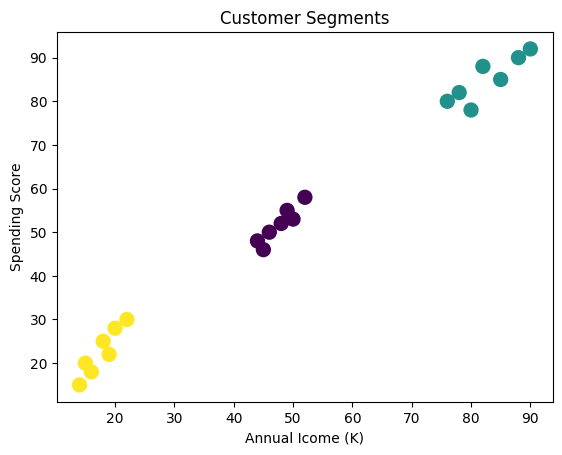

In [8]:
plt.scatter(df['annual_income'], df['spending_score'],
c= df['cluster'], s= 100, cmap='viridis')

plt.xlabel("Annual Icome (K)")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

Centroid(income, spending) [[47.7 51.7]
 [82.7 85. ]
 [17.7 22.6]]


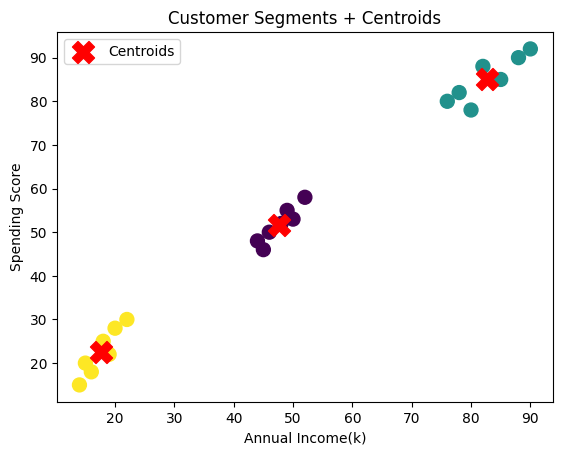

In [14]:
centroids = model.cluster_centers_

print('Centroid(income, spending)', np.round(centroids, 1))

plt.scatter(df['annual_income'], df['spending_score'],
            c= df['cluster'], s = 100, cmap = 'viridis')

plt.scatter(centroids[:,0], centroids[:,1],
            c = 'red', marker = "X", s = 250, label = "Centroids" )

plt.xlabel("Annual Income(k)"); plt.ylabel("Spending Score")
plt.title("Customer Segments + Centroids");plt.legend()

plt.show()

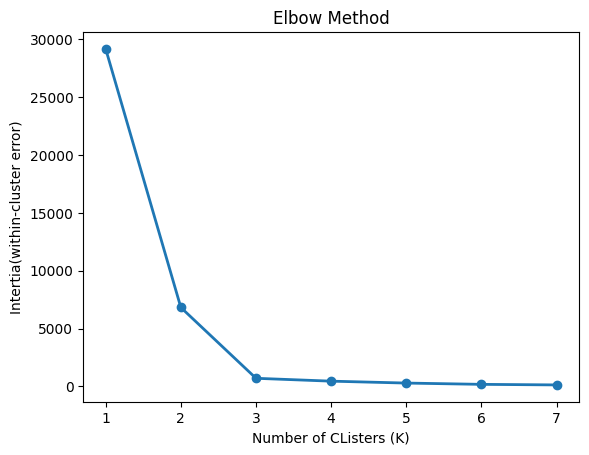

In [15]:
inertias = []

for k in range(1, 8):
  km = KMeans(n_clusters = k, random_state=42, n_init=10).fit(X)
  inertias.append(km.inertia_)

plt.plot(range(1,8), inertias, "o-", linewidth=2)
plt.xlabel("Number of CListers (K)")
plt.ylabel("Intertia(within-cluster error)")
plt.title("Elbow Method")
plt.show()